# Mô hình dự đoán `is_canceled` — Random Forest v1.2

Phiên bản **v1.2** kế thừa v1.1 và bổ sung **feature engineering** theo 4 nhóm biến:

### Nhóm 1 — Mức độ cam kết tài chính (Financial Commitment)
| Biến | Công thức |
|------|----------|
| `total_guests` | `adults + children + babies` |
| `price_per_person` | `adr / total_guests` |
| `is_family` | 1 nếu `children > 0` hoặc `babies > 0`, ngược lại 0 |

### Nhóm 2 — Cấu trúc chuyến đi (Trip Structure)
| Biến | Công thức |
|------|----------|
| `total_nights` | `stays_in_weekend_nights + stays_in_week_nights` |
| `lead_time_per_night` | `lead_time / total_nights` |

### Nhóm 3 — Lịch sử và uy tín (Trust & History)
| Biến | Công thức |
|------|----------|
| `history_cancel_rate` | `previous_cancellations / (previous_cancellations + previous_bookings_not_canceled)` |

### Nhóm 4 — Lịch & mùa (Calendar & Seasonality)
| Biến | Công thức |
|------|----------|
| `is_weekend_only` | 1 nếu chỉ ở cuối tuần (`weekend_nights > 0` và `week_nights == 0`) |
| `arrival_month_mapped` | Tháng đến ánh xạ số 1–12 (Jan→1 … Dec→12) |

Giữ nguyên 6 biến phân loại v1.1 + `lead_time`, `total_of_special_requests`. Thay `previous_cancellations` bằng `history_cancel_rate`.

**Ngưỡng dự đoán:** `P(hủy) >= 0.35` → dự đoán **Hủy**.

**Nguyên tắc chống Data Leakage:**
1. Chỉ đọc feature + target cần thiết — **không** nạp `reservation_status`, `revenue`, `Occupancy_Rate`, `RevPAR`, ...
2. Feature engineering chỉ dùng thông tin có tại thời điểm đặt phòng.
3. `train_test_split` **trước** mọi bước tiền xử lý mã hóa.
4. `OneHotEncoder` chỉ `fit` trên tập train (qua `Pipeline` + `ColumnTransformer`).


In [9]:
import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42
TEST_SIZE = 0.2
DATA_BASENAME = "hotel_bookings"
VERSION_PATTERN = re.compile(rf"^{DATA_BASENAME}_v(\d+)\.csv$", re.IGNORECASE)

LEAKAGE_COLUMNS = {
    "reservation_status",
    "reservation_status_date",
    "revenue",
    "Occupancy_Rate",
    "RevPAR",
}

PREDICTION_THRESHOLD = 0.35

MONTH_ORDER = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]
MONTH_TO_NUM = {month: i + 1 for i, month in enumerate(MONTH_ORDER)}

CATEGORICAL_FEATURES = [
    "deposit_type",
    "market_segment",
    "country",
    "distribution_channel",
    "customer_type",
    "hotel",
]

RAW_COLUMNS_FOR_ENGINEERING = [
    "adults", "children", "babies", "adr",
    "stays_in_weekend_nights", "stays_in_week_nights",
    "previous_bookings_not_canceled", "arrival_date_month",
]

NUMERIC_FEATURES = [
    "lead_time",
    "total_of_special_requests",
    "total_guests",
    "price_per_person",
    "is_family",
    "total_nights",
    "lead_time_per_night",
    "history_cancel_rate",
    "is_weekend_only",
    "arrival_month_mapped",
]
FEATURE_COLUMNS = CATEGORICAL_FEATURES + NUMERIC_FEATURES
TARGET_COLUMN = "is_canceled"


def _data_search_roots() -> list[Path]:
    notebook_dir = Path(os.environ.get("VSCODE_NOTEBOOK_DIR", Path.cwd()))
    search_roots = [
        notebook_dir / "data",
        notebook_dir,
        notebook_dir.parent / "data",
        notebook_dir.parent,
        notebook_dir.parent.parent,
        Path.cwd() / "data",
        Path.cwd(),
    ]
    path = Path.cwd()
    for _ in range(6):
        search_roots.extend([path / "data", path])
        path = path.parent

    seen, roots = set(), []
    for root in search_roots:
        try:
            root = root.resolve()
        except OSError:
            continue
        if root not in seen:
            seen.add(root)
            roots.append(root)
    return roots


def find_latest_versioned_data_file() -> Path:
    candidates: list[tuple[int, Path]] = []
    for root in _data_search_roots():
        if not root.is_dir():
            continue
        for file_path in root.glob(f"{DATA_BASENAME}_v*.csv"):
            if "test" in file_path.name.lower():
                continue
            match = VERSION_PATTERN.match(file_path.name)
            if match:
                candidates.append((int(match.group(1)), file_path.resolve()))

    if not candidates:
        raise FileNotFoundError(f"Không tìm thấy file '{DATA_BASENAME}_v*.csv'")

    latest_version, latest_path = max(candidates, key=lambda item: item[0])
    print(f"Chọn file v{latest_version} mới nhất: {latest_path.name}")
    return latest_path


csv_path = find_latest_versioned_data_file()
print(f"Đang đọc: {csv_path}")

read_columns = list(
    dict.fromkeys(
        CATEGORICAL_FEATURES
        + ["lead_time", "total_of_special_requests"]
        + RAW_COLUMNS_FOR_ENGINEERING
        + ["previous_cancellations"]
        + [TARGET_COLUMN]
    )
)
df = pd.read_csv(csv_path, usecols=read_columns)

print(f"Số booking: {len(df):,}")
print(f"Tỷ lệ hủy: {df[TARGET_COLUMN].mean() * 100:.2f}%")
print(f"\nCột leakage đã loại: {sorted(LEAKAGE_COLUMNS)}")
df.head()


Chọn file v5 mới nhất: hotel_bookings_v5.csv
Đang đọc: C:\Users\ADMIN\OneDrive\Tài liệu\oneDrive\Desktop\DA\Project\Hotel Booking Demand\Python\data\hotel_bookings_v5.csv
Số booking: 82,811
Tỷ lệ hủy: 28.12%

Cột leakage đã loại: ['Occupancy_Rate', 'RevPAR', 'reservation_status', 'reservation_status_date', 'revenue']


,hotel,is_canceled,lead_time,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,country,market_segment,distribution_channel,previous_cancellations,previous_bookings_not_canceled,deposit_type,customer_type,adr,total_of_special_requests
0,Resort Hotel,0,342,July,0,0,2,0,0,PRT,Direct,Direct,0,0,No Deposit,Transient,0.0,0
1,Resort Hotel,0,737,July,0,0,2,0,0,PRT,Direct,Direct,0,0,No Deposit,Transient,0.0,0
2,Resort Hotel,0,7,July,0,1,1,0,0,GBR,Direct,Direct,0,0,No Deposit,Transient,75.0,0
3,Resort Hotel,0,13,July,0,1,1,0,0,GBR,Corporate,Corporate,0,0,No Deposit,Transient,75.0,0
4,Resort Hotel,0,14,July,0,2,2,0,0,GBR,Online TA,TA/TO,0,0,No Deposit,Transient,98.0,1


## 1. Feature engineering & kiểm tra dữ liệu

Tạo 9 biến engineered từ cột thô, xử lý edge case (chia cho 0), rồi chuẩn bị ma trận `X`.


In [10]:
def engineer_features(raw: pd.DataFrame) -> pd.DataFrame:
    """Tạo biến engineered v1.2 từ cột thô (thông tin có tại thời điểm đặt)."""
    out = raw.copy()

    out["children"] = out["children"].fillna(0)
    out["total_guests"] = out["adults"] + out["children"] + out["babies"]
    out["total_guests"] = out["total_guests"].clip(lower=1)

    out["price_per_person"] = out["adr"] / out["total_guests"]
    out["is_family"] = (
        (out["children"] > 0) | (out["babies"] > 0)
    ).astype(int)

    out["total_nights"] = (
        out["stays_in_weekend_nights"] + out["stays_in_week_nights"]
    )
    out["lead_time_per_night"] = out["lead_time"] / out["total_nights"].clip(lower=1)

    prior_total = (
        out["previous_cancellations"] + out["previous_bookings_not_canceled"]
    )
    out["history_cancel_rate"] = np.where(
        prior_total > 0,
        out["previous_cancellations"] / prior_total,
        0.0,
    )

    out["is_weekend_only"] = (
        (out["stays_in_weekend_nights"] > 0) & (out["stays_in_week_nights"] == 0)
    ).astype(int)

    out["arrival_month_mapped"] = (
        out["arrival_date_month"].map(MONTH_TO_NUM).fillna(0).astype(int)
    )

    return out


print("=== Missing values (cột thô) ===")
print(df[RAW_COLUMNS_FOR_ENGINEERING + ["previous_cancellations"]].isna().sum())

engineered_df = engineer_features(df)

print("\n=== Biến engineered (describe) ===")
engineered_cols = [
    "total_guests", "price_per_person", "is_family",
    "total_nights", "lead_time_per_night", "history_cancel_rate",
    "is_weekend_only", "arrival_month_mapped",
]
display(engineered_df[engineered_cols].describe().T)

model_df = engineered_df[FEATURE_COLUMNS + [TARGET_COLUMN]].copy()
model_df["country"] = model_df["country"].fillna("Unknown").astype(str)
for col in CATEGORICAL_FEATURES:
    model_df[col] = model_df[col].astype(str)

int_like = [
    "lead_time", "total_of_special_requests", "total_guests", "is_family",
    "total_nights", "is_weekend_only", "arrival_month_mapped",
]
float_like = ["price_per_person", "lead_time_per_night", "history_cancel_rate"]
for col in int_like:
    model_df[col] = model_df[col].fillna(0).astype(int)
for col in float_like:
    model_df[col] = model_df[col].fillna(0.0).astype(float)

X = model_df[FEATURE_COLUMNS]
y = model_df[TARGET_COLUMN].astype(int)

print(f"\nKích thước X: {X.shape} ({len(CATEGORICAL_FEATURES)} phân loại + {len(NUMERIC_FEATURES)} số)")
print(f"Phân bố y: {y.value_counts().to_dict()}")


=== Missing values (cột thô) ===
adults                            0
children                          0
babies                            0
adr                               0
stays_in_weekend_nights           0
stays_in_week_nights              0
previous_bookings_not_canceled    0
arrival_date_month                0
previous_cancellations            0
dtype: int64

=== Biến engineered (describe) ===


,count,mean,std,min,25%,50%,75%,max
total_guests,82811.0,2.044861,0.797066,1.00,2.00,2.000000,2.0,55.0
price_per_person,82811.0,55.694585,29.939480,-3.19,38.00,50.000000,67.5,2700.0
is_family,82811.0,0.108585,0.311119,0.00,0.00,0.000000,0.0,1.0
total_nights,82811.0,3.674705,2.786843,0.00,2.00,3.000000,5.0,69.0
lead_time_per_night,82811.0,25.199919,36.216372,0.00,4.25,14.428571,32.0,737.0
history_cancel_rate,82811.0,0.013364,0.110402,0.00,0.00,0.000000,0.0,1.0
is_weekend_only,82811.0,0.062902,0.242789,0.00,0.00,0.000000,0.0,1.0
arrival_month_mapped,82811.0,6.467390,3.088011,1.00,4.00,7.000000,9.0,12.0



Kích thước X: (82811, 16) (6 phân loại + 10 số)
Phân bố y: {0: 59527, 1: 23284}


## 2. Train / Test split (trước khi mã hóa)

Tách dữ liệu **trước** mọi bước fit encoder để tránh leakage từ tập test vào quá trình học category.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Tỷ lệ hủy train: {y_train.mean() * 100:.2f}%")
print(f"Tỷ lệ hủy test:  {y_test.mean() * 100:.2f}%")

Train: 66,248 | Test: 16,563
Tỷ lệ hủy train: 28.12%
Tỷ lệ hủy test:  28.12%


## 3. Pipeline: One-Hot + biến số → Random Forest

- **OneHotEncoder** cho biến phân loại; biến số đi **passthrough** (Random Forest không cần scale).
- `min_frequency=5`: gộp category hiếm thành `infrequent` — chỉ học từ train.
- Dự đoán nhị phân dùng ngưỡng **0,35**: `y_pred = (P(hủy) >= 0.35)`.

In [12]:
categorical_encoder = OneHotEncoder(
    handle_unknown="infrequent_if_exist",
    min_frequency=5,
    sparse_output=False,
)

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_encoder, CATEGORICAL_FEATURES),
        ("num", "passthrough", NUMERIC_FEATURES),
    ],
    remainder="drop",
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                min_samples_leaf=20,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

rf_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

## 4. Huấn luyện & đánh giá

In [13]:
rf_pipeline.fit(X_train, y_train)

y_proba = rf_pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= PREDICTION_THRESHOLD).astype(int)

print(f"=== Classification Report (Test) — ngưỡng {PREDICTION_THRESHOLD} ===")
print(classification_report(y_test, y_pred, target_names=["Không hủy", "Hủy"]))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC (test): {roc_auc:.4f}")

cv_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)
print(f"\nCV ROC-AUC (5-fold, train only): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

y_pred_default = (y_proba >= 0.5).astype(int)
print(f"\n--- So sánh F1 class Hủy: ngưỡng 0.5 vs {PREDICTION_THRESHOLD} ---")
print(f"F1 @ 0.50: {f1_score(y_test, y_pred_default, pos_label=1):.4f}")
print(f"F1 @ {PREDICTION_THRESHOLD:.2f}: {f1_score(y_test, y_pred, pos_label=1):.4f}")

=== Classification Report (Test) — ngưỡng 0.35 ===
              precision    recall  f1-score   support

   Không hủy       0.95      0.49      0.65     11906
         Hủy       0.42      0.94      0.58      4657

    accuracy                           0.62     16563
   macro avg       0.69      0.72      0.62     16563
weighted avg       0.80      0.62      0.63     16563

ROC-AUC (test): 0.8396

CV ROC-AUC (5-fold, train only): 0.8376 ± 0.0042

--- So sánh F1 class Hủy: ngưỡng 0.5 vs 0.35 ---
F1 @ 0.50: 0.6127
F1 @ 0.35: 0.5809


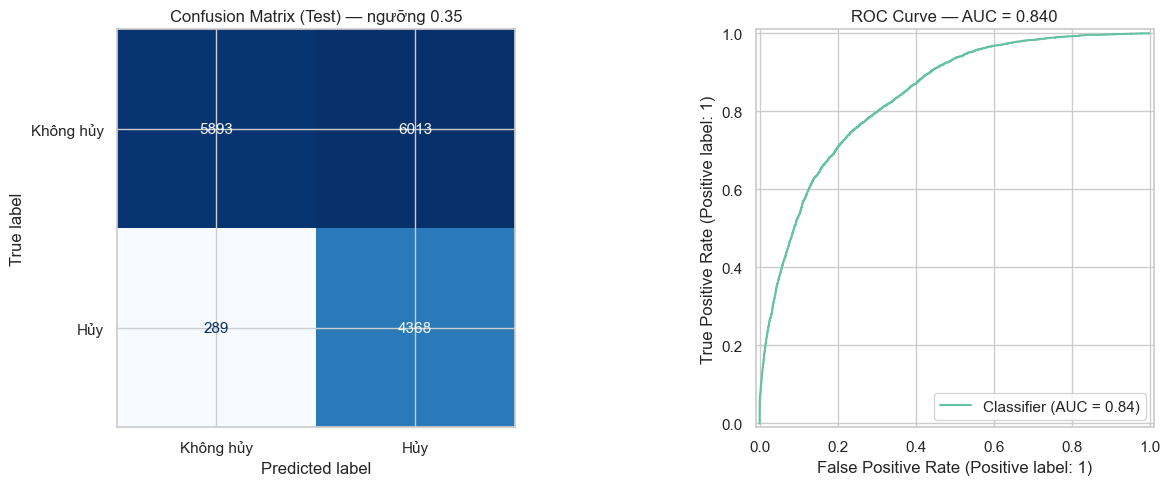

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Không hủy", "Hủy"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title(f"Confusion Matrix (Test) — ngưỡng {PREDICTION_THRESHOLD}")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title(f"ROC Curve — AUC = {roc_auc:.3f}")

plt.tight_layout()
plt.show()

## 5. Phân phối xác suất dự đoán (Prediction Probability Distribution)

So sánh phân phối `P(hủy)` giữa booking **thực sự không hủy** và **thực sự hủy** trên tập test.

**Quy ước màu:** teal = Không hủy · orange = Hủy · đường đứt nét = ngưỡng **0,35** (v1.1).

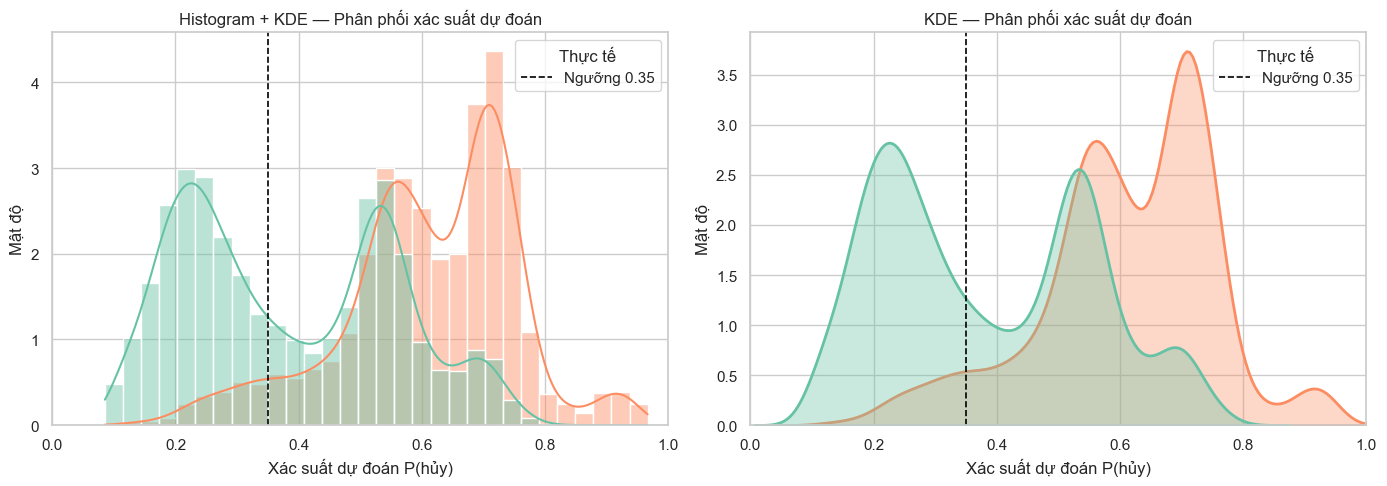

=== Thống kê P(hủy) theo nhãn thực tế (test) ===


,n,mean,median,std
actual,,,,
Không hủy,11906,0.3838,0.3537,0.1725
Hủy,4657,0.6120,0.6267,0.1427


In [15]:
proba_df = pd.DataFrame(
    {
        "probability": y_proba,
        "actual": np.where(y_test == 1, "Hủy", "Không hủy"),
    }
)

# Đảo màu Set2: teal = Không hủy, orange = Hủy (mặc định seaborn gán ngược lại)
LABEL_ORDER = ["Không hủy", "Hủy"]
LABEL_PALETTE = {"Không hủy": "#66c2a5", "Hủy": "#fc8d62"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram + KDE chồng lên nhau
sns.histplot(
    data=proba_df,
    x="probability",
    hue="actual",
    hue_order=LABEL_ORDER,
    palette=LABEL_PALETTE,
    bins=30,
    kde=True,
    stat="density",
    common_norm=False,
    alpha=0.45,
    ax=axes[0],
)
axes[0].axvline(PREDICTION_THRESHOLD, color="black", linestyle="--", linewidth=1.2, label=f"Ngưỡng {PREDICTION_THRESHOLD}")
axes[0].set_xlabel("Xác suất dự đoán P(hủy)")
axes[0].set_ylabel("Mật độ")
axes[0].set_title("Histogram + KDE — Phân phối xác suất dự đoán")
axes[0].set_xlim(0, 1)
axes[0].legend(title="Thực tế")

# KDE thuần — dễ nhìn sự tách lớp
sns.kdeplot(
    data=proba_df,
    x="probability",
    hue="actual",
    hue_order=LABEL_ORDER,
    palette=LABEL_PALETTE,
    fill=True,
    common_norm=False,
    alpha=0.35,
    linewidth=2,
    ax=axes[1],
)
axes[1].axvline(PREDICTION_THRESHOLD, color="black", linestyle="--", linewidth=1.2, label=f"Ngưỡng {PREDICTION_THRESHOLD}")
axes[1].set_xlabel("Xác suất dự đoán P(hủy)")
axes[1].set_ylabel("Mật độ")
axes[1].set_title("KDE — Phân phối xác suất dự đoán")
axes[1].set_xlim(0, 1)
axes[1].legend(title="Thực tế")

plt.tight_layout()
plt.show()

# Thống kê tóm tắt
summary = (
    proba_df.groupby("actual", observed=True)["probability"]
    .agg(["count", "mean", "median", "std"])
    .rename(columns={"count": "n"})
    .reindex(LABEL_ORDER)
)
print("=== Thống kê P(hủy) theo nhãn thực tế (test) ===")
display(summary.round(4))

## 6. Feature Importance

Sau tiền xử lý, mỗi category thành cột One-Hot; biến số giữ nguyên tên. Top 20 cột quan trọng nhất.

Số cột sau One-Hot Encoding: 139

Top 20 feature quan trọng nhất:


,feature,importance
0,lead_time,0.141115
1,country_PRT,0.112650
2,market_segment_Online TA,0.110503
3,lead_time_per_night,0.108044
4,total_of_special_requests,0.084939
5,market_segment_Offline TA/TO,0.055920
6,customer_type_Transient,0.041952
7,history_cancel_rate,0.032745
8,distribution_channel_TA/TO,0.028999
9,customer_type_Transient-Party,0.028313


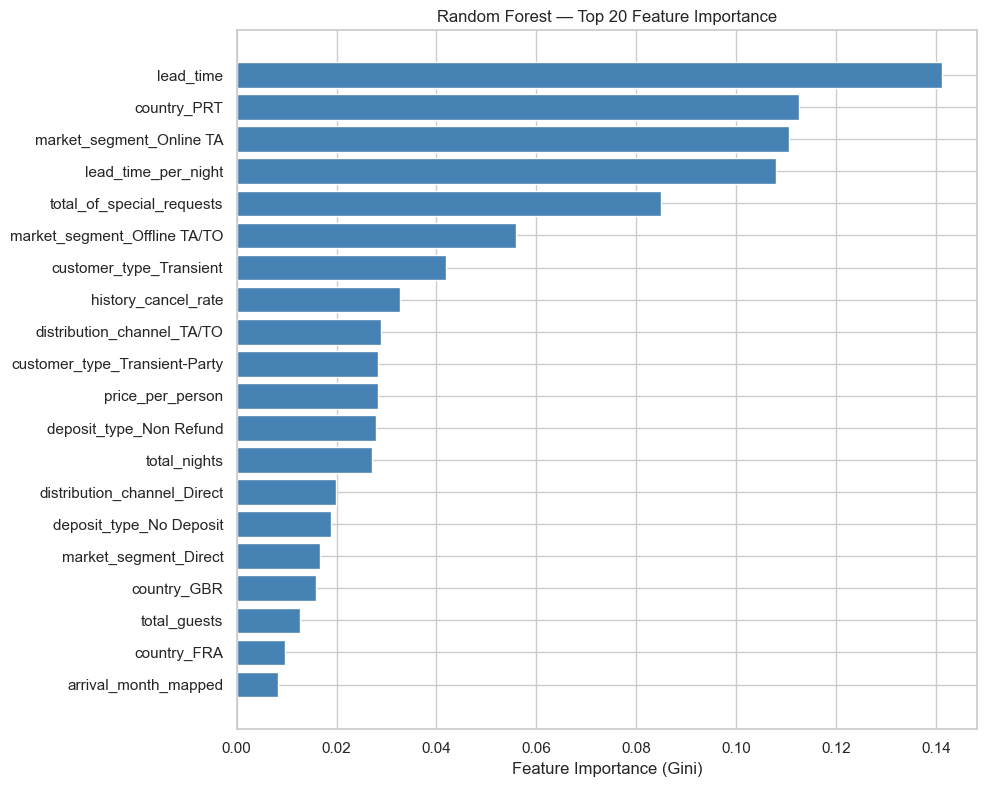


Tổng importance theo biến gốc:


,source,importance
11,market,0.194555
1,country,0.164172
9,lead_time,0.141115
10,lead_time_per_night,0.108044
15,total_of_special_requests,0.084939
2,customer,0.076890
4,distribution,0.054404
3,deposit,0.046849
5,history_cancel_rate,0.032745
12,price_per_person,0.028285


In [16]:
preprocessor_fitted = rf_pipeline.named_steps["preprocessor"]
cat_encoder = preprocessor_fitted.named_transformers_["cat"]
cat_names = cat_encoder.get_feature_names_out(CATEGORICAL_FEATURES)
feature_names = np.concatenate([cat_names, np.array(NUMERIC_FEATURES, dtype=object)])
importances = rf_pipeline.named_steps["classifier"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

print(f"Số cột sau One-Hot Encoding: {len(feature_names)}")
print("\nTop 20 feature quan trọng nhất:")
display(importance_df.head(20))

top_n = 20
plot_df = importance_df.head(top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df["feature"], plot_df["importance"], color="steelblue")
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title(f"Random Forest — Top {top_n} Feature Importance")
plt.tight_layout()
plt.show()

# Tổng hợp importance theo biến gốc
importance_df["source"] = importance_df["feature"].apply(
    lambda x: x if x in NUMERIC_FEATURES else x.split("_", 1)[0]
)
grouped = (
    importance_df.groupby("source", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)
print("\nTổng importance theo biến gốc:")
display(grouped)

## 7. Giải thích SHAP — Đóng góp biến engineered

Dùng **SHAP** (`TreeExplainer`) trên ma trận đã qua `ColumnTransformer` để đo **mức độ và hướng** mỗi biến engineered tác động tới `P(hủy)`.

- **SHAP > 0** → đẩy xác suất hủy **tăng**
- **SHAP < 0** → đẩy xác suất hủy **giảm**
- **|SHAP| lớn** → đóng góp mạnh vào quyết định

Lấy mẫu **2.000** booking từ tập test để cân bằng tốc độ và độ ổn định.

=== Mean |SHAP| — biến engineered (class Hủy) ===


,feature,mean_abs_shap,mean_shap,group
0,lead_time_per_night,0.03160,-0.00519,Trip Structure
1,price_per_person,0.01091,-0.00225,Financial Commitment
2,total_nights,0.01000,-0.00058,Trip Structure
3,history_cancel_rate,0.00638,-0.00140,Trust & History
4,total_guests,0.00422,-0.00036,Financial Commitment
5,arrival_month_mapped,0.00261,-0.00032,Calendar & Seasonality
6,is_family,0.00217,-0.00013,Financial Commitment
7,is_weekend_only,0.00137,-0.00008,Calendar & Seasonality



=== Tổng |SHAP| theo nhóm biến ===


,group,mean_abs_shap,mean_shap
2,Trip Structure,0.04160,-0.00577
1,Financial Commitment,0.01729,-0.00275
3,Trust & History,0.00638,-0.00140
0,Calendar & Seasonality,0.00399,-0.00040


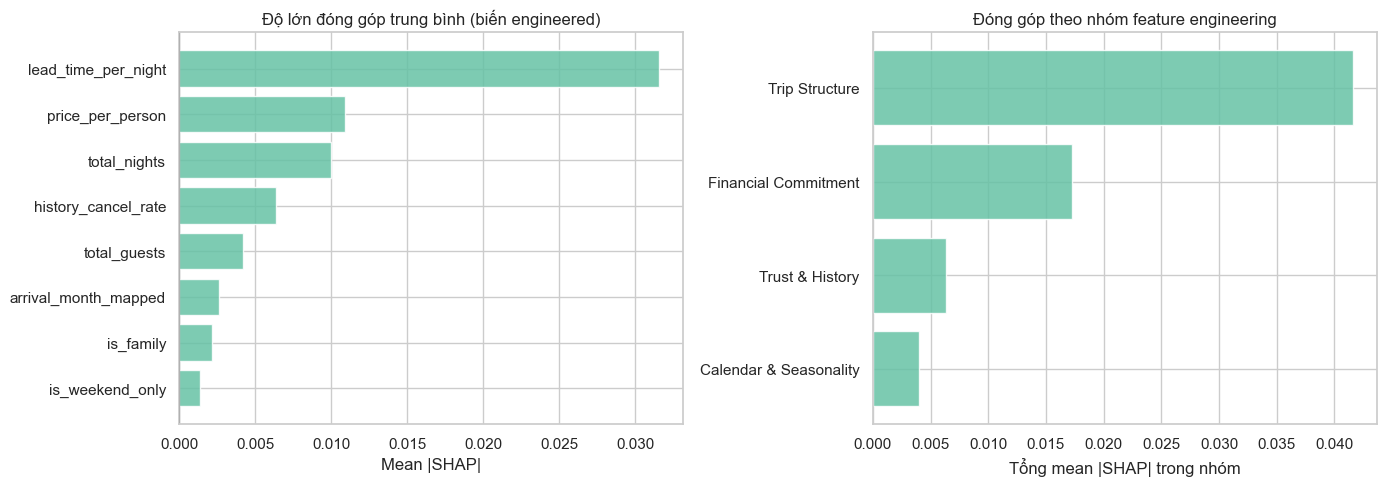

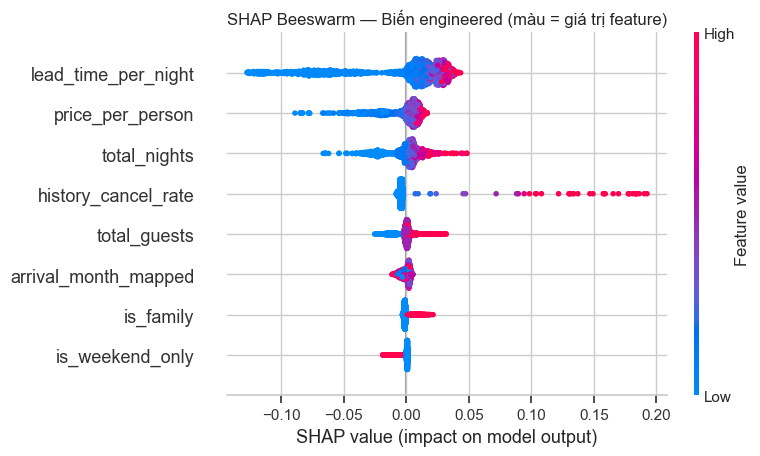

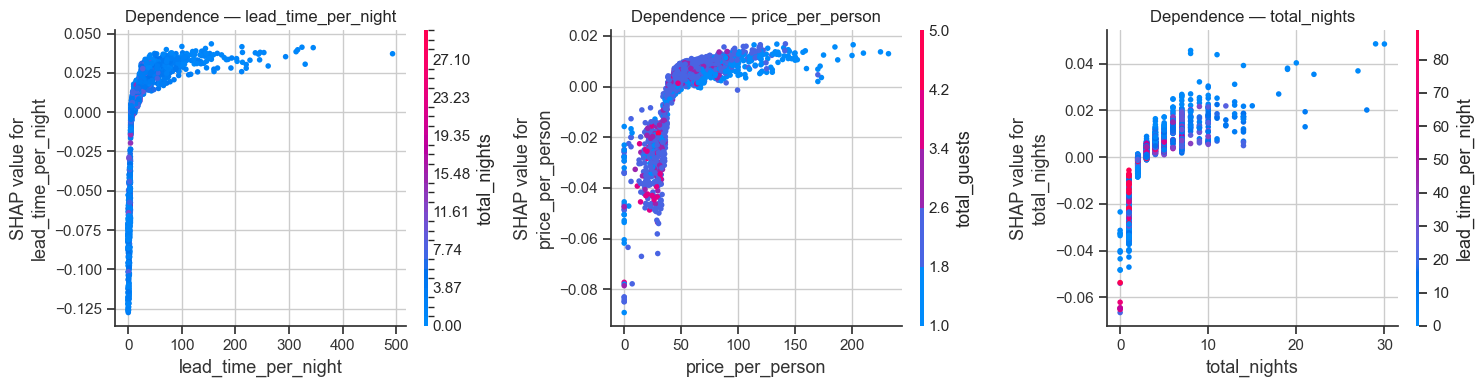

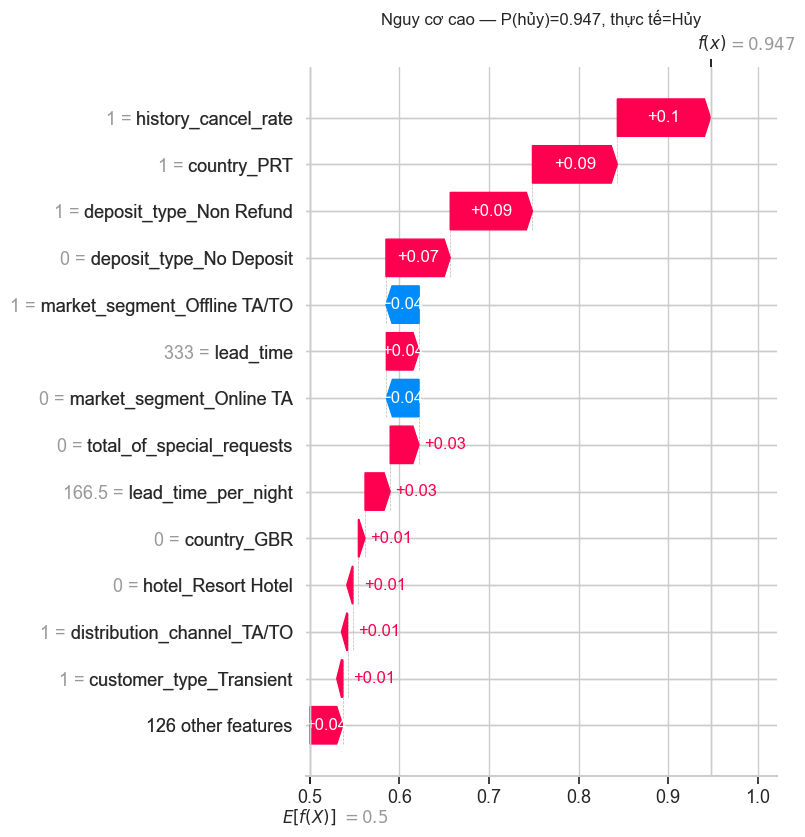

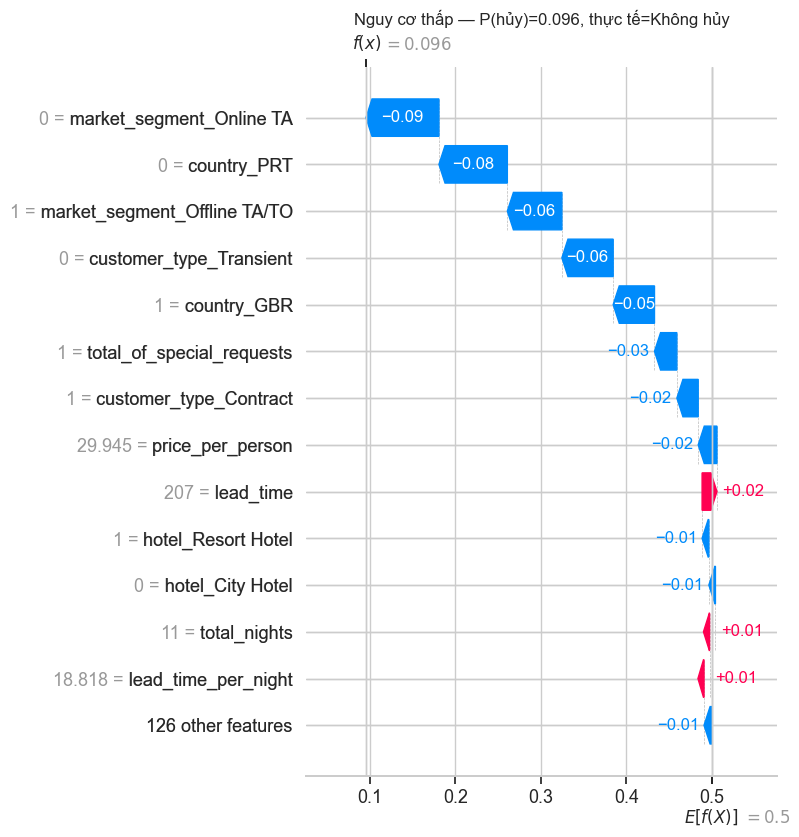

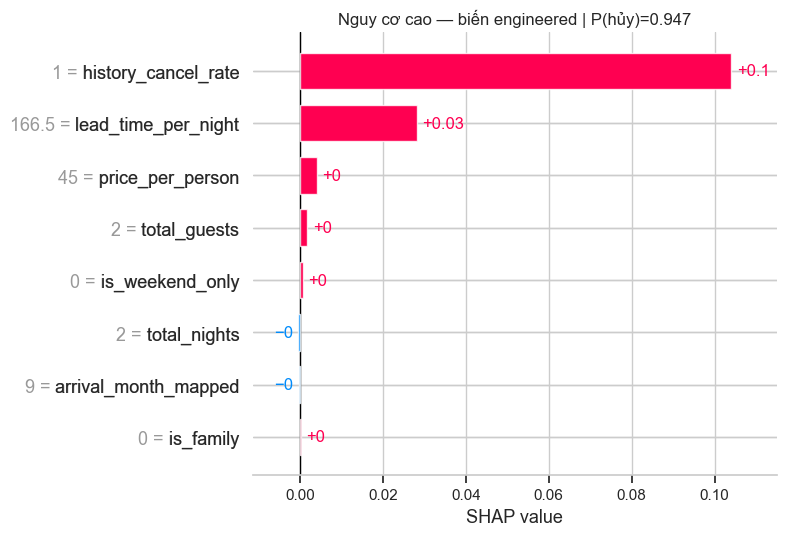

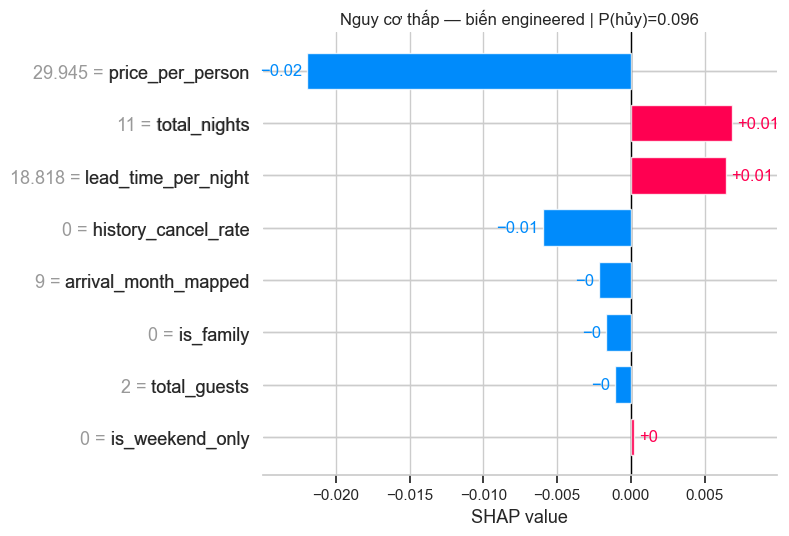

In [17]:
import shap

ENGINEERED_FEATURES = [
    "total_guests",
    "price_per_person",
    "is_family",
    "total_nights",
    "lead_time_per_night",
    "history_cancel_rate",
    "is_weekend_only",
    "arrival_month_mapped",
]
ENGINEERED_GROUPS = {
    "Financial Commitment": ["total_guests", "price_per_person", "is_family"],
    "Trip Structure": ["total_nights", "lead_time_per_night"],
    "Trust & History": ["history_cancel_rate"],
    "Calendar & Seasonality": ["is_weekend_only", "arrival_month_mapped"],
}
SHAP_SAMPLE_SIZE = 2_000

preprocessor_fitted = rf_pipeline.named_steps["preprocessor"]
classifier = rf_pipeline.named_steps["classifier"]

if "feature_names" not in globals():
    cat_encoder = preprocessor_fitted.named_transformers_["cat"]
    cat_names = cat_encoder.get_feature_names_out(CATEGORICAL_FEATURES)
    feature_names = np.concatenate([cat_names, np.array(NUMERIC_FEATURES, dtype=object)])

X_test_transformed = preprocessor_fitted.transform(X_test)
rng = np.random.default_rng(RANDOM_STATE)
n_shap = min(SHAP_SAMPLE_SIZE, len(X_test))
sample_idx = rng.choice(len(X_test), size=n_shap, replace=False)
X_shap_matrix = X_test_transformed[sample_idx]
y_shap = y_test.iloc[sample_idx].values

explainer = shap.TreeExplainer(classifier)
shap_all = explainer.shap_values(X_shap_matrix)
shap_values = shap_all[:, :, 1]
base_value = explainer.expected_value[1]
sample_proba = classifier.predict_proba(X_shap_matrix)[:, 1]

eng_col_idx = [int(np.where(feature_names == f)[0][0]) for f in ENGINEERED_FEATURES]
shap_eng = shap_values[:, eng_col_idx]
X_eng = pd.DataFrame(X_shap_matrix[:, eng_col_idx], columns=ENGINEERED_FEATURES)

feature_to_group = {f: g for g, feats in ENGINEERED_GROUPS.items() for f in feats}

shap_eng_summary = (
    pd.DataFrame(
        {
            "feature": ENGINEERED_FEATURES,
            "mean_abs_shap": np.abs(shap_eng).mean(axis=0),
            "mean_shap": shap_eng.mean(axis=0),
        }
    )
    .assign(group=lambda d: d["feature"].map(feature_to_group))
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

print("=== Mean |SHAP| — biến engineered (class Hủy) ===")
display(shap_eng_summary.round(5))

group_shap = (
    shap_eng_summary.groupby("group", as_index=False)
    .agg(mean_abs_shap=("mean_abs_shap", "sum"), mean_shap=("mean_shap", "sum"))
    .sort_values("mean_abs_shap", ascending=False)
)
print("\n=== Tổng |SHAP| theo nhóm biến ===")
display(group_shap.round(5))

# --- 1. Bar chart: đóng góp trung bình từng biến engineered ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = shap_eng_summary.sort_values("mean_abs_shap", ascending=True)
colors = plot_df["mean_shap"].apply(lambda v: "#fc8d62" if v > 0 else "#66c2a5")
axes[0].barh(plot_df["feature"], plot_df["mean_abs_shap"], color=colors, alpha=0.85)
axes[0].set_xlabel("Mean |SHAP|")
axes[0].set_title("Độ lớn đóng góp trung bình (biến engineered)")
axes[0].axvline(0, color="black", linewidth=0.8)

group_plot = group_shap.sort_values("mean_abs_shap", ascending=True)
gcolors = group_plot["mean_shap"].apply(lambda v: "#fc8d62" if v > 0 else "#66c2a5")
axes[1].barh(group_plot["group"], group_plot["mean_abs_shap"], color=gcolors, alpha=0.85)
axes[1].set_xlabel("Tổng mean |SHAP| trong nhóm")
axes[1].set_title("Đóng góp theo nhóm feature engineering")
plt.tight_layout()
plt.show()

# --- 2. Beeswarm: phân bố SHAP theo giá trị feature ---
shap.summary_plot(
    shap_eng,
    X_eng,
    feature_names=ENGINEERED_FEATURES,
    plot_type="dot",
    show=False,
    max_display=len(ENGINEERED_FEATURES),
)
plt.title("SHAP Beeswarm — Biến engineered (màu = giá trị feature)")
plt.tight_layout()
plt.show()

# --- 3. Dependence plot: top 3 biến engineered ---
top_eng = shap_eng_summary.head(3)["feature"].tolist()
fig, axes = plt.subplots(1, len(top_eng), figsize=(5 * len(top_eng), 4))
if len(top_eng) == 1:
    axes = [axes]
for ax, feat in zip(axes, top_eng):
    j = ENGINEERED_FEATURES.index(feat)
    shap.dependence_plot(
        j,
        shap_eng,
        X_eng,
        feature_names=ENGINEERED_FEATURES,
        ax=ax,
        show=False,
    )
    ax.set_title(f"Dependence — {feat}")
plt.tight_layout()
plt.show()

# --- 4. Waterfall: 1 booking dự đoán Hủy, 1 booking dự đoán Không hủy ---
high_risk_idx = int(np.argmax(sample_proba))
low_risk_idx = int(np.argmin(sample_proba))

for row_idx, risk_label in [
    (high_risk_idx, "Nguy cơ cao"),
    (low_risk_idx, "Nguy cơ thấp"),
]:
    actual = "Hủy" if y_shap[row_idx] else "Không hủy"
    title = f"{risk_label} — P(hủy)={sample_proba[row_idx]:.3f}, thực tế={actual}"
    exp = shap.Explanation(
        values=shap_values[row_idx],
        base_values=base_value,
        data=X_shap_matrix[row_idx],
        feature_names=feature_names,
    )
    shap.plots.waterfall(exp, max_display=14, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# --- 5. Chỉ các biến engineered trong 2 ví dụ trên ---
for row_idx, risk_label in [
    (high_risk_idx, "Nguy cơ cao"),
    (low_risk_idx, "Nguy cơ thấp"),
]:
    exp_eng = shap.Explanation(
        values=shap_eng[row_idx],
        base_values=base_value,
        data=X_eng.iloc[row_idx].values,
        feature_names=ENGINEERED_FEATURES,
    )
    shap.plots.bar(exp_eng, max_display=len(ENGINEERED_FEATURES), show=False)
    plt.title(f"{risk_label} — biến engineered | P(hủy)={sample_proba[row_idx]:.3f}")
    plt.tight_layout()
    plt.show()


## 8. Tóm tắt v1.2

| Bước | Cách xử lý |
|------|------------|
| Loại leakage | Không đọc `reservation_status`, `revenue`, `Occupancy_Rate`, `RevPAR`, ... |
| Feature engineering | 9 biến mới theo 4 nhóm (Financial, Trip, Trust, Calendar) |
| Phân loại | `OneHotEncoder` → cột nhị phân 0/1 |
| Biến số | 10 biến passthrough (gồm `lead_time`, `total_of_special_requests` + 8 engineered) |
| Chống leakage | `train_test_split` trước; `Pipeline` fit chỉ trên train |
| Ngưỡng | **`P(hủy) >= 0.35`** → dự đoán Hủy |
| Mô hình | `RandomForestClassifier` (300 cây, `class_weight='balanced'`) |

**Khác v1.1:** bổ sung feature engineering theo nhóm; thay `previous_cancellations` bằng `history_cancel_rate`; thêm tín hiệu cấu trúc chuyến đi, cam kết tài chính và mùa vụ.
